In [1]:
import pandas as pandas
import os
import glob


In [2]:
#searches the csv files
csv_files = glob.glob("../data/raw/MERGED_CSV/**/*.csv", recursive=True)
print("Number of CSV files:", len(csv_files))
for file in csv_files[:10]:
    print(file)

Number of CSV files: 63
../data/raw/MERGED_CSV\Merged01.csv
../data/raw/MERGED_CSV\Merged02.csv
../data/raw/MERGED_CSV\Merged03.csv
../data/raw/MERGED_CSV\Merged04.csv
../data/raw/MERGED_CSV\Merged05.csv
../data/raw/MERGED_CSV\Merged06.csv
../data/raw/MERGED_CSV\Merged07.csv
../data/raw/MERGED_CSV\Merged08.csv
../data/raw/MERGED_CSV\Merged09.csv
../data/raw/MERGED_CSV\Merged10.csv


In [3]:
import pandas as pd
df=pd.read_csv(csv_files[0])
print("Shape:",df.shape)
print(df.head())

Shape: (712311, 40)
   Header_Length  Protocol Type  Time_To_Live          Rate  fin_flag_number  \
0          19.92              6         63.36  25893.962218              0.0   
1           0.00             47         64.00   3703.841331              0.0   
2           7.92             17         65.91  19673.095685              0.0   
3          20.40              6        110.50    261.664826              0.1   
4           0.32              1         63.96  28944.199848              0.0   

   syn_flag_number  rst_flag_number  psh_flag_number  ack_flag_number  \
0              0.0              0.0             0.99             0.99   
1              0.0              0.0             0.00             0.00   
2              0.0              0.0             0.00             0.00   
3              0.0              0.3             0.20             0.40   
4              0.0              0.0             0.00             0.01   

   ece_flag_number  ...  Tot sum  Min   Max     AVG         

In [4]:
df.columns.tolist

<bound method IndexOpsMixin.tolist of Index(['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate',
       'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
       'psh_flag_number', 'ack_flag_number', 'ece_flag_number',
       'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count',
       'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP',
       'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max',
       'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Variance', 'Label'],
      dtype='object')>

In [5]:
df.columns[-5:]

Index(['Tot size', 'IAT', 'Number', 'Variance', 'Label'], dtype='object')

In [6]:
df.tail()

,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,...,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Variance,Label
712306,20.0,6,64.00,33177.535200,0.00,1.0,0.00,0.00,0.00,0.0,...,6000,60,60,60.00,0.0,60.00,0.000034,100,0.00,DDOS-SYN_FLOOD
712307,8.0,17,64.00,49038.980475,0.00,0.0,0.00,0.00,0.00,0.0,...,6000,60,60,60.00,0.0,60.00,0.000020,100,0.00,DOS-UDP_FLOOD
712308,20.0,6,67.82,10496.518932,0.98,0.0,0.98,0.01,0.02,0.0,...,6061,60,121,60.61,6.1,60.61,0.000102,100,37.21,DDOS-RSTFINFLOOD
712309,20.0,6,64.00,23321.123158,0.00,1.0,0.00,0.00,0.00,0.0,...,6000,60,60,60.00,0.0,60.00,0.000048,100,0.00,DDOS-SYNONYMOUSIP_FLOOD
712310,0.0,1,64.00,49778.115357,0.00,0.0,0.00,0.00,0.00,0.0,...,6000,60,60,60.00,0.0,60.00,0.000020,100,0.00,DDOS-ICMP_FLOOD


In [7]:
df["Label"].value_counts()

Label
DDOS-ICMP_FLOOD            108662
DDOS-UDP_FLOOD              82011
DDOS-TCP_FLOOD              68289
DDOS-PSHACK_FLOOD           62171
DDOS-RSTFINFLOOD            61652
DDOS-SYN_FLOOD              61460
DDOS-SYNONYMOUSIP_FLOOD     54749
DOS-UDP_FLOOD               50371
DOS-TCP_FLOOD               40391
DOS-SYN_FLOOD               30620
BENIGN                      16577
MIRAI-GREETH_FLOOD          15135
MIRAI-UDPPLAIN              13342
MIRAI-GREIP_FLOOD           11187
DDOS-ICMP_FRAGMENTATION      6784
VULNERABILITYSCAN            5805
MITM-ARPSPOOFING             4590
DDOS-ACK_FRAGMENTATION       4308
DDOS-UDP_FRAGMENTATION       4264
DNS_SPOOFING                 2738
RECON-HOSTDISCOVERY          2045
RECON-OSSCAN                 1433
RECON-PORTSCAN               1251
DOS-HTTP_FLOOD               1113
DDOS-HTTP_FLOOD               416
DDOS-SLOWLORIS                354
DICTIONARYBRUTEFORCE          204
BROWSERHIJACKING               83
SQLINJECTION                   77
COMMANDI

In [8]:
print("Number of unique labels:", df["Label"].nunique())
print(df["Label"].unique())

Number of unique labels: 34
['DDOS-PSHACK_FLOOD' 'MIRAI-GREIP_FLOOD' 'DOS-UDP_FLOOD' 'DNS_SPOOFING'
 'DDOS-ICMP_FLOOD' 'DDOS-TCP_FLOOD' 'DDOS-SYN_FLOOD' 'DDOS-UDP_FLOOD'
 'MITM-ARPSPOOFING' 'DDOS-SYNONYMOUSIP_FLOOD' 'DOS-TCP_FLOOD'
 'VULNERABILITYSCAN' 'DOS-SYN_FLOOD' 'DDOS-RSTFINFLOOD' 'BENIGN'
 'DDOS-SLOWLORIS' 'DDOS-ICMP_FRAGMENTATION' 'MIRAI-GREETH_FLOOD'
 'RECON-HOSTDISCOVERY' 'MIRAI-UDPPLAIN' 'RECON-PORTSCAN'
 'DDOS-ACK_FRAGMENTATION' 'DDOS-UDP_FRAGMENTATION' 'RECON-OSSCAN'
 'BACKDOOR_MALWARE' 'DOS-HTTP_FLOOD' 'XSS' 'DDOS-HTTP_FLOOD'
 'BROWSERHIJACKING' 'SQLINJECTION' 'DICTIONARYBRUTEFORCE'
 'COMMANDINJECTION' 'RECON-PINGSWEEP' 'UPLOADING_ATTACK']


In [9]:
for file in csv_files:
    temp = pd.read_csv(file, nrows=5)
    print(
        os.path.basename(file),
        "→",
        temp.shape[1],
        "columns"
    )

Merged01.csv → 40 columns
Merged02.csv → 40 columns
Merged03.csv → 40 columns
Merged04.csv → 40 columns
Merged05.csv → 40 columns
Merged06.csv → 40 columns
Merged07.csv → 40 columns
Merged08.csv → 40 columns
Merged09.csv → 40 columns
Merged10.csv → 40 columns
Merged11.csv → 40 columns
Merged12.csv → 40 columns
Merged13.csv → 40 columns
Merged14.csv → 40 columns
Merged15.csv → 40 columns
Merged16.csv → 40 columns
Merged17.csv → 40 columns
Merged18.csv → 40 columns
Merged19.csv → 40 columns
Merged20.csv → 40 columns
Merged21.csv → 40 columns
Merged22.csv → 40 columns
Merged23.csv → 40 columns
Merged24.csv → 40 columns
Merged25.csv → 40 columns
Merged26.csv → 40 columns
Merged27.csv → 40 columns
Merged28.csv → 40 columns
Merged29.csv → 40 columns
Merged30.csv → 40 columns
Merged31.csv → 40 columns
Merged32.csv → 40 columns
Merged33.csv → 40 columns
Merged34.csv → 40 columns
Merged35.csv → 40 columns
Merged36.csv → 40 columns
Merged37.csv → 40 columns
Merged38.csv → 40 columns
Merged39.csv

In [10]:
all_columns_same = all(
    pd.read_csv(file, nrows=0).columns.tolist() == df.columns.tolist()
    for file in csv_files
)

print("All files have same columns:", all_columns_same)

All files have same columns: True


In [11]:
#dfs = [pd.read_csv(file) for file in csv_files]

#full_df = pd.concat(dfs, ignore_index=True)

#print("Combined shape:", full_df.shape)

In [12]:
# print(full_df.shape)
# print(full_df.columns.tolist())

In [13]:
# print(full_df.memory_usage(deep=True).sum() / (1024**3), "GB")

In [14]:
# print(full_df.columns.tolist())

In [15]:
# print(full_df.dtypes)

In [16]:
# del full_df
# del dfs

# import gc
# # gc.collect()

In [17]:
MAX_PER_CLASS = 10_000
CHUNK_SIZE = 50_000

class_samples = {}

In [18]:
for file in csv_files:
    print("Processing:", os.path.basename(file))

    for chunk in pd.read_csv(file, chunksize=CHUNK_SIZE):
        
        for label, group in chunk.groupby("Label"):
            
            if label not in class_samples:
                class_samples[label] = group.copy()
            else:
                class_samples[label] = pd.concat(
                    [class_samples[label], group],
                    ignore_index=True
                )

            # Keep at most MAX_PER_CLASS samples
            if len(class_samples[label]) > MAX_PER_CLASS:
                class_samples[label] = class_samples[label].sample(
                    n=MAX_PER_CLASS,
                    random_state=42
                ).reset_index(drop=True)

Processing: Merged01.csv


Processing: Merged02.csv
Processing: Merged03.csv
Processing: Merged04.csv
Processing: Merged05.csv
Processing: Merged06.csv
Processing: Merged07.csv
Processing: Merged08.csv
Processing: Merged09.csv
Processing: Merged10.csv
Processing: Merged11.csv
Processing: Merged12.csv
Processing: Merged13.csv
Processing: Merged14.csv
Processing: Merged15.csv
Processing: Merged16.csv
Processing: Merged17.csv
Processing: Merged18.csv
Processing: Merged19.csv
Processing: Merged20.csv
Processing: Merged21.csv
Processing: Merged22.csv
Processing: Merged23.csv
Processing: Merged24.csv
Processing: Merged25.csv
Processing: Merged26.csv
Processing: Merged27.csv
Processing: Merged28.csv
Processing: Merged29.csv
Processing: Merged30.csv
Processing: Merged31.csv
Processing: Merged32.csv
Processing: Merged33.csv
Processing: Merged34.csv
Processing: Merged35.csv
Processing: Merged36.csv
Processing: Merged37.csv
Processing: Merged38.csv
Processing: Merged39.csv
Processing: Merged40.csv
Processing: Merged41.csv


In [19]:
sampled_df = pd.concat(
    class_samples.values(),
    ignore_index=True
)

print("Sampled shape:", sampled_df.shape)

Sampled shape: (295960, 40)


In [20]:
print(sampled_df["Label"].value_counts())

Label
DNS_SPOOFING               10000
VULNERABILITYSCAN          10000
RECON-PORTSCAN             10000
RECON-OSSCAN               10000
RECON-HOSTDISCOVERY        10000
MITM-ARPSPOOFING           10000
MIRAI-UDPPLAIN             10000
MIRAI-GREIP_FLOOD          10000
MIRAI-GREETH_FLOOD         10000
DOS-UDP_FLOOD              10000
DOS-TCP_FLOOD              10000
DOS-SYN_FLOOD              10000
DOS-HTTP_FLOOD             10000
BENIGN                     10000
DICTIONARYBRUTEFORCE       10000
DDOS-UDP_FRAGMENTATION     10000
DDOS-UDP_FLOOD             10000
DDOS-TCP_FLOOD             10000
DDOS-SYN_FLOOD             10000
DDOS-SYNONYMOUSIP_FLOOD    10000
DDOS-SLOWLORIS             10000
DDOS-RSTFINFLOOD           10000
DDOS-PSHACK_FLOOD          10000
DDOS-ICMP_FRAGMENTATION    10000
DDOS-ICMP_FLOOD            10000
DDOS-HTTP_FLOOD            10000
DDOS-ACK_FRAGMENTATION     10000
BROWSERHIJACKING            5630
COMMANDINJECTION            5168
SQLINJECTION                5022
XSS 

In [21]:
print("Missing values:", sampled_df.isnull().sum().sum())

Missing values: 20


In [22]:
print("Duplicate rows:", sampled_df.duplicated().sum())

Duplicate rows: 8710


In [23]:
import numpy as np

print("Infinite values:", np.isinf(sampled_df.select_dtypes(include=np.number)).sum().sum())

Infinite values: 13


In [24]:
import numpy as np
sampled_df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [25]:
sampled_df.drop_duplicates(inplace=True)
sampled_df.reset_index(drop=True, inplace=True)

In [26]:
print(sampled_df.isnull().sum().sum())

27


In [27]:
print(sampled_df.isnull().sum()[sampled_df.isnull().sum() > 0])

Rate        11
Std          8
Variance     8
dtype: int64


In [28]:
#Using the training-set median ideally after splitting, to avoid any preprocessing leakage.
from sklearn.model_selection import train_test_split

X = sampled_df.drop(columns=["Label"])
y = sampled_df["Label"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (201075, 39)
Validation: (43087, 39)
Test: (43088, 39)


In [29]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_val = label_encoder.transform(y_val)
y_test = label_encoder.transform(y_test)

print("Number of classes:", len(label_encoder.classes_))
print(label_encoder.classes_)

Number of classes: 34
['BACKDOOR_MALWARE' 'BENIGN' 'BROWSERHIJACKING' 'COMMANDINJECTION'
 'DDOS-ACK_FRAGMENTATION' 'DDOS-HTTP_FLOOD' 'DDOS-ICMP_FLOOD'
 'DDOS-ICMP_FRAGMENTATION' 'DDOS-PSHACK_FLOOD' 'DDOS-RSTFINFLOOD'
 'DDOS-SLOWLORIS' 'DDOS-SYNONYMOUSIP_FLOOD' 'DDOS-SYN_FLOOD'
 'DDOS-TCP_FLOOD' 'DDOS-UDP_FLOOD' 'DDOS-UDP_FRAGMENTATION'
 'DICTIONARYBRUTEFORCE' 'DNS_SPOOFING' 'DOS-HTTP_FLOOD' 'DOS-SYN_FLOOD'
 'DOS-TCP_FLOOD' 'DOS-UDP_FLOOD' 'MIRAI-GREETH_FLOOD' 'MIRAI-GREIP_FLOOD'
 'MIRAI-UDPPLAIN' 'MITM-ARPSPOOFING' 'RECON-HOSTDISCOVERY' 'RECON-OSSCAN'
 'RECON-PINGSWEEP' 'RECON-PORTSCAN' 'SQLINJECTION' 'UPLOADING_ATTACK'
 'VULNERABILITYSCAN' 'XSS']


In [67]:
import numpy as np

class_counts = Counter(y_train)
total = len(y_train)

class_weights = {
    cls: total / count
    for cls, count in class_counts.items()
}

sample_weights = np.array([
    class_weights[label]
    for label in y_train
])

print("Minimum weight:", sample_weights.min())
print("Maximum weight:", sample_weights.max())

Minimum weight: 28.725
Maximum weight: 240.23297491039426


In [30]:
#for xgboost
#no sclaing for xg as it is a tree based model
X_train_xgb = X_train.copy()
X_val_xgb = X_val.copy()
X_test_xgb = X_test.copy()

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_ft = scaler.fit_transform(X_train)
X_val_ft = scaler.transform(X_val)
X_test_ft = scaler.transform(X_test)

print(X_train_ft.shape)
print(X_val_ft.shape)
print(X_test_ft.shape)

(201075, 39)
(43087, 39)
(43088, 39)


In [32]:
#checking if teh split is right 
print("Train classes:", len(set(y_train)))
print("Validation classes:", len(set(y_val)))
print("Test classes:", len(set(y_test)))

Train classes: 34
Validation classes: 34
Test classes: 34


XGBoost

In [33]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
from xgboost import XGBClassifier

In [35]:
xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=34,
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

In [36]:
xgb_model.fit(
    X_train_xgb,
    y_train,
    eval_set=[(X_val_xgb, y_val)],
    verbose=True
)

[0]	validation_0-mlogloss:2.62993
[1]	validation_0-mlogloss:2.34475
[2]	validation_0-mlogloss:2.13540
[3]	validation_0-mlogloss:1.97401
[4]	validation_0-mlogloss:1.84350
[5]	validation_0-mlogloss:1.73353
[6]	validation_0-mlogloss:1.63946
[7]	validation_0-mlogloss:1.55880
[8]	validation_0-mlogloss:1.48765
[9]	validation_0-mlogloss:1.42478
[10]	validation_0-mlogloss:1.36909
[11]	validation_0-mlogloss:1.31920
[12]	validation_0-mlogloss:1.27455
[13]	validation_0-mlogloss:1.23459
[14]	validation_0-mlogloss:1.19832
[15]	validation_0-mlogloss:1.16524
[16]	validation_0-mlogloss:1.13504
[17]	validation_0-mlogloss:1.10759
[18]	validation_0-mlogloss:1.08214
[19]	validation_0-mlogloss:1.05912
[20]	validation_0-mlogloss:1.03809
[21]	validation_0-mlogloss:1.01888
[22]	validation_0-mlogloss:1.00116
[23]	validation_0-mlogloss:0.98460
[24]	validation_0-mlogloss:0.96952
[25]	validation_0-mlogloss:0.95562
[26]	validation_0-mlogloss:0.94287
[27]	validation_0-mlogloss:0.93092
[28]	validation_0-mlogloss:0.9

,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets impo

In [37]:
y_pred_xgb = xgb_model.predict(X_test_xgb)
print(y_pred_xgb)

[ 7 21 11 ... 22 20  4]


In [38]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Macro F1:", f1_score(y_test, y_pred_xgb, average="macro"))
print("Weighted F1:", f1_score(y_test, y_pred_xgb, average="weighted"))

Accuracy: 0.7099656516895655
Macro F1: 0.6478492119604199
Weighted F1: 0.7040821727490358


In [39]:
print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=label_encoder.classes_
))

                         precision    recall  f1-score   support

       BACKDOOR_MALWARE       0.32      0.23      0.27       461
                 BENIGN       0.47      0.67      0.55      1500
       BROWSERHIJACKING       0.62      0.53      0.57       834
       COMMANDINJECTION       0.44      0.43      0.43       772
 DDOS-ACK_FRAGMENTATION       0.99      0.99      0.99      1500
        DDOS-HTTP_FLOOD       0.89      0.86      0.88      1500
        DDOS-ICMP_FLOOD       1.00      1.00      1.00      1345
DDOS-ICMP_FRAGMENTATION       0.99      0.99      0.99      1500
      DDOS-PSHACK_FLOOD       1.00      1.00      1.00      1406
       DDOS-RSTFINFLOOD       1.00      1.00      1.00      1367
         DDOS-SLOWLORIS       0.94      0.99      0.97      1500
DDOS-SYNONYMOUSIP_FLOOD       0.45      0.62      0.52      1385
         DDOS-SYN_FLOOD       0.45      0.27      0.34      1398
         DDOS-TCP_FLOOD       0.65      0.56      0.60      1340
         DDOS-UDP_FLOOD 

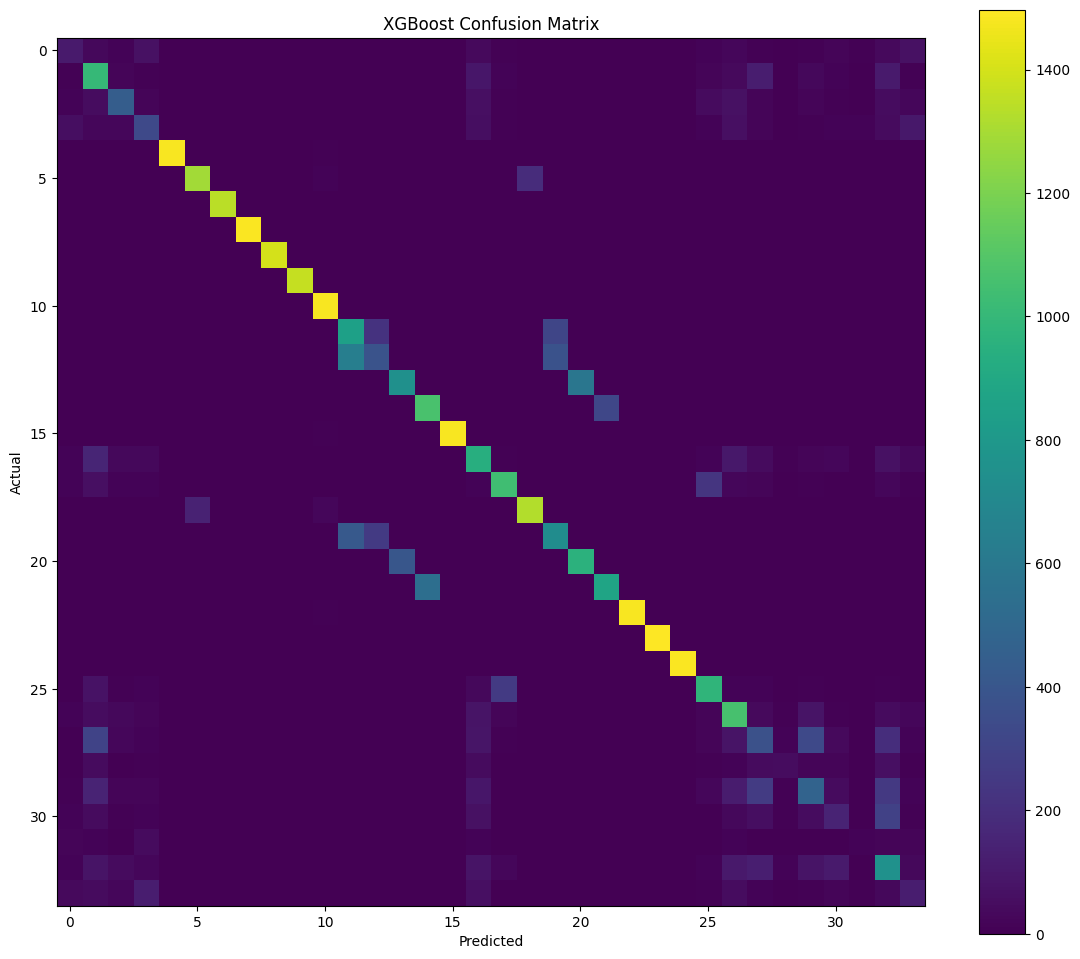

In [40]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(14, 12))
plt.imshow(cm)
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

In [41]:
print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=label_encoder.classes_,
    digits=3
))

                         precision    recall  f1-score   support

       BACKDOOR_MALWARE      0.324     0.234     0.272       461
                 BENIGN      0.470     0.669     0.552      1500
       BROWSERHIJACKING      0.616     0.531     0.571       834
       COMMANDINJECTION      0.437     0.426     0.431       772
 DDOS-ACK_FRAGMENTATION      0.995     0.988     0.991      1500
        DDOS-HTTP_FLOOD      0.895     0.860     0.877      1500
        DDOS-ICMP_FLOOD      0.999     0.999     0.999      1345
DDOS-ICMP_FRAGMENTATION      0.991     0.992     0.992      1500
      DDOS-PSHACK_FLOOD      0.999     0.998     0.998      1406
       DDOS-RSTFINFLOOD      1.000     0.998     0.999      1367
         DDOS-SLOWLORIS      0.943     0.989     0.966      1500
DDOS-SYNONYMOUSIP_FLOOD      0.446     0.616     0.517      1385
         DDOS-SYN_FLOOD      0.447     0.274     0.340      1398
         DDOS-TCP_FLOOD      0.653     0.563     0.604      1340
         DDOS-UDP_FLOOD 

In [42]:
%pip install rtdl_revisiting_models

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
import torch
import torch.nn as nn
from rtdl_revisiting_models import FTTransformer

print(torch.__version__)

2.10.0+cpu


In [48]:
import torch

X_train_tensor = torch.tensor(X_train_ft, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_ft, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_ft, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print(X_train_tensor.shape)
print(y_train_tensor.shape)

torch.Size([201075, 39])
torch.Size([201075])


In [50]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cpu


In [52]:
from rtdl_revisiting_models import FTTransformer

model = FTTransformer(
    n_cont_features=39,
    cat_cardinalities=None,
    d_out=34,
    **FTTransformer.get_default_kwargs()
)

model = model.to(device)

print(model)

FTTransformer(
  (cls_embedding): _CLSEmbedding()
  (cont_embeddings): LinearEmbeddings()
  (backbone): FTTransformerBackbone(
    (blocks): ModuleList(
      (0): ModuleDict(
        (attention): MultiheadAttention(
          (W_q): Linear(in_features=192, out_features=192, bias=True)
          (W_k): Linear(in_features=192, out_features=192, bias=True)
          (W_v): Linear(in_features=192, out_features=192, bias=True)
          (W_out): Linear(in_features=192, out_features=192, bias=True)
          (dropout): Dropout(p=0.2, inplace=False)
        )
        (attention_residual_dropout): Dropout(p=0.0, inplace=False)
        (ffn_normalization): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
        (ffn): Sequential(
          (linear1): Linear(in_features=192, out_features=512, bias=True)
          (activation): _ReGLU()
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=256, out_features=192, bias=True)
        )
        (ffn_residua

In [53]:
print("Parameters:", sum(p.numel() for p in model.parameters()))

Parameters: 913186


In [54]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=512,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=512,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 393
Validation batches: 85


In [55]:
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

In [56]:
print("Loss:", criterion)
print("Optimizer:", optimizer.__class__.__name__)

Loss: CrossEntropyLoss()
Optimizer: AdamW


In [57]:
EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch, None)

        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # Validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch, None)

            loss = criterion(logits, y_batch)
            val_loss += loss.item()

            predictions = logits.argmax(dim=1)
            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

    val_loss /= len(val_loader)
    val_accuracy = correct / total

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

Epoch 1/10 | Train Loss: nan | Val Loss: nan | Val Acc: 0.0107


KeyboardInterrupt: 

In [ ]:
model(X_batch, None)

In [58]:
from collections import Counter

class_counts = Counter(y_train)

for cls, count in sorted(class_counts.items(), key=lambda x: x[1]):
    print(label_encoder.classes_[cls], count)

UPLOADING_ATTACK 837
RECON-PINGSWEEP 1513
BACKDOOR_MALWARE 2153
XSS 2593
SQLINJECTION 3515
COMMANDINJECTION 3605
BROWSERHIJACKING 3892
DDOS-TCP_FLOOD 6256
DDOS-ICMP_FLOOD 6279
DOS-TCP_FLOOD 6373
DDOS-RSTFINFLOOD 6381
DDOS-SYNONYMOUSIP_FLOOD 6466
DDOS-UDP_FLOOD 6506
DDOS-SYN_FLOOD 6523
DDOS-PSHACK_FLOOD 6558
DOS-SYN_FLOOD 6604
MITM-ARPSPOOFING 6631
DOS-UDP_FLOOD 6644
DNS_SPOOFING 6912
RECON-PORTSCAN 6942
RECON-OSSCAN 6961
MIRAI-UDPPLAIN 6980
RECON-HOSTDISCOVERY 6987
DOS-HTTP_FLOOD 6988
MIRAI-GREIP_FLOOD 6994
VULNERABILITYSCAN 6995
MIRAI-GREETH_FLOOD 6996
BENIGN 6997
DDOS-UDP_FRAGMENTATION 6998
DDOS-ACK_FRAGMENTATION 6998
DICTIONARYBRUTEFORCE 6999
DDOS-ICMP_FRAGMENTATION 6999
DDOS-HTTP_FLOOD 7000
DDOS-SLOWLORIS 7000


In [59]:
from collections import Counter

class_counts = Counter(y_train)

for cls, count in sorted(class_counts.items(), key=lambda x: x[1]):
    print(label_encoder.classes_[cls], count)

UPLOADING_ATTACK 837
RECON-PINGSWEEP 1513
BACKDOOR_MALWARE 2153
XSS 2593
SQLINJECTION 3515
COMMANDINJECTION 3605
BROWSERHIJACKING 3892
DDOS-TCP_FLOOD 6256
DDOS-ICMP_FLOOD 6279
DOS-TCP_FLOOD 6373
DDOS-RSTFINFLOOD 6381
DDOS-SYNONYMOUSIP_FLOOD 6466
DDOS-UDP_FLOOD 6506
DDOS-SYN_FLOOD 6523
DDOS-PSHACK_FLOOD 6558
DOS-SYN_FLOOD 6604
MITM-ARPSPOOFING 6631
DOS-UDP_FLOOD 6644
DNS_SPOOFING 6912
RECON-PORTSCAN 6942
RECON-OSSCAN 6961
MIRAI-UDPPLAIN 6980
RECON-HOSTDISCOVERY 6987
DOS-HTTP_FLOOD 6988
MIRAI-GREIP_FLOOD 6994
VULNERABILITYSCAN 6995
MIRAI-GREETH_FLOOD 6996
BENIGN 6997
DDOS-UDP_FRAGMENTATION 6998
DDOS-ACK_FRAGMENTATION 6998
DICTIONARYBRUTEFORCE 6999
DDOS-ICMP_FRAGMENTATION 6999
DDOS-HTTP_FLOOD 7000
DDOS-SLOWLORIS 7000


In [68]:
xgb_weighted = XGBClassifier(
    objective="multi:softprob",
    num_class=34,
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgb_weighted.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets impo

In [69]:
y_pred_weighted = xgb_weighted.predict(X_test)

In [70]:
print(classification_report(
    y_test,
    y_pred_weighted,
    target_names=label_encoder.classes_,
    digits=3
))

                         precision    recall  f1-score   support

       BACKDOOR_MALWARE      0.228     0.321     0.266       461
                 BENIGN      0.500     0.627     0.556      1500
       BROWSERHIJACKING      0.512     0.555     0.533       834
       COMMANDINJECTION      0.421     0.386     0.403       772
 DDOS-ACK_FRAGMENTATION      0.996     0.988     0.992      1500
        DDOS-HTTP_FLOOD      0.889     0.857     0.873      1500
        DDOS-ICMP_FLOOD      1.000     0.999     1.000      1345
DDOS-ICMP_FRAGMENTATION      0.991     0.992     0.992      1500
      DDOS-PSHACK_FLOOD      0.999     0.998     0.999      1406
       DDOS-RSTFINFLOOD      1.000     0.998     0.999      1367
         DDOS-SLOWLORIS      0.938     0.989     0.963      1500
DDOS-SYNONYMOUSIP_FLOOD      0.446     0.623     0.520      1385
         DDOS-SYN_FLOOD      0.444     0.288     0.350      1398
         DDOS-TCP_FLOOD      0.647     0.584     0.614      1340
         DDOS-UDP_FLOOD 

In [71]:
y_pred_train_weighted = xgb_weighted.predict(X_train)

print("Training Accuracy:",
      accuracy_score(y_train, y_pred_train_weighted))

print("Test Accuracy:",
      accuracy_score(y_test, y_pred_weighted))

print("Training Macro F1:",
      f1_score(y_train, y_pred_train_weighted, average="macro"))

print("Test Macro F1:",
      f1_score(y_test, y_pred_weighted, average="macro"))

Training Accuracy: 0.8931194827800572
Test Accuracy: 0.7051615298923134
Training Macro F1: 0.8914685044223274
Test Macro F1: 0.648467493209183


In [72]:
y_pred_train_xgb = xgb_model.predict(X_train)

print("Original XGBoost")
print("Training Accuracy:", accuracy_score(y_train, y_pred_train_xgb))
print("Test Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("Training Macro F1:", f1_score(y_train, y_pred_train_xgb, average="macro"))
print("Test Macro F1:", f1_score(y_test, y_pred_xgb, average="macro"))

Original XGBoost
Training Accuracy: 0.8602710431431058
Test Accuracy: 0.7099656516895655
Training Macro F1: 0.8548662568314148
Test Macro F1: 0.6478492119604199


In [66]:
print(xgb_model.get_params())

{'objective': 'multi:softprob', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': True, 'eval_metric': 'mlogloss', 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.1, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 8, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 300, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.8, 'tree_method': 'hist', 'validate_parameters': None, 'verbosity': None, 'num_class': 34}
